# Implementing a Feedforward Neural Network from Scratch

This notebook aims to build a simple feedforward neural network using only `numpy`, without relying on higher-level deep learning frameworks. We will cover the core components:

1.  **Initialization**: Setting up the network's layers, weights, and biases.
2.  **Activation Functions**: Applying non-linearity (e.g., Sigmoid, ReLU).
3.  **Forward Pass**: Calculating predictions.
4.  **Loss Function**: Quantifying the error (e.g., Mean Squared Error).
5.  **Backpropagation**: Calculating gradients of the loss with respect to weights and biases.
6.  **Gradient Descent**: Updating weights and biases to minimize loss.
7.  **Training**: Iterating through the dataset to learn the optimal parameters.
8.  **Displaying updated weights** for each epoch.

## 1. Imports and Helper Functions

First, we'll import `numpy` for numerical operations and define common activation functions (and their derivatives) and a loss function.

In [32]:
import numpy as np

# --- Activation Functions ---

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def linear(x):
    return x

def linear_derivative(x):
    return np.ones_like(x)


# --- Loss Function ---

def mse_loss(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))

def mse_loss_derivative(y_true, y_pred):
    return 2 * (y_pred - y_true) / y_true.size

## 2. Neural Network Class Structure

Now, let's define the `NeuralNetwork` class. It will handle the initialization of layers, forward pass, backpropagation, and weight updates.

In [33]:
class NeuralNetwork:
    def __init__(self, layer_dims, activation_fn_names):
        self.num_layers = len(layer_dims)
        self.layer_dims = layer_dims
        self.weights = {}
        self.biases = {}
        self.activations = {}

        # Initialize weights and biases
        for l in range(1, self.num_layers):
            self.weights['W' + str(l)] = np.random.randn(self.layer_dims[l], self.layer_dims[l-1]) * 0.1 # Increased initialization scale
            self.biases['b' + str(l)] = np.zeros((self.layer_dims[l], 1))

        # Map activation function names to actual functions and their derivatives
        self.activation_functions = {
            'sigmoid': sigmoid,
            'relu': relu,
            'linear': linear
        }
        self.activation_derivatives = {
            'sigmoid': sigmoid_derivative,
            'relu': relu_derivative,
            'linear': linear_derivative
        }
        self.activation_fn_names = activation_fn_names # List of activation names for each layer

    def forward(self, X):
        # Stores all activation values (A) and pre-activation values (Z) for backprop
        self.cache = {}
        self.activations_history = {f'A{l}': [] for l in range(1, self.num_layers)}
        A = X.T # Input is the first activation

        for l in range(1, self.num_layers):
            W = self.weights['W' + str(l)]
            b = self.biases['b' + str(l)]
            Z = np.dot(W, A) + b

            activation_name = self.activation_fn_names[l-1] # Get activation for current layer
            activation_func = self.activation_functions[activation_name]

            A = activation_func(Z)

            self.cache['A' + str(l-1)] = A if l > 1 else X.T # Store previous layer's activation
            self.cache['Z' + str(l)] = Z
            self.cache['A' + str(l)] = A
            self.activations_history[f'A{l}'].append(A.copy())

        return A.T # Return output as (m, num_output_nodes)

    def backward(self, X, Y, Y_pred):
        grads = {}
        m = X.shape[0]

        # Initial gradient for the output layer
        dL_dY_pred = mse_loss_derivative(Y.T, Y_pred.T) # (output_nodes, m)

        for l in reversed(range(1, self.num_layers)):
            Z = self.cache['Z' + str(l)]
            A_prev = self.cache['A' + str(l-1)]

            activation_name = self.activation_fn_names[l-1]
            activation_deriv_func = self.activation_derivatives[activation_name]

            dZ = dL_dY_pred * activation_deriv_func(Z)
            dW = (1 / m) * np.dot(dZ, A_prev.T)
            db = (1 / m) * np.sum(dZ, axis=1, keepdims=True)

            # For the next iteration, propagate gradient back to the previous layer
            if l > 1:
                W_curr = self.weights['W' + str(l)]
                dL_dY_pred = np.dot(W_curr.T, dZ)

            grads['dW' + str(l)] = dW
            grads['db' + str(l)] = db

        return grads

    def train(self, X, Y, learning_rate, num_epochs):
        self.weights_history = {f'W{l}': [] for l in range(1, self.num_layers)}
        self.biases_history = {f'b{l}': [] for l in range(1, self.num_layers)}

        for epoch in range(1, num_epochs + 1):
            # Forward pass
            Y_pred = self.forward(X)

            # Calculate loss
            loss = mse_loss(Y, Y_pred)

            # Backward pass (calculate gradients)
            grads = self.backward(X, Y, Y_pred)

            # Update weights and biases (gradient descent)
            for l in range(1, self.num_layers):
                self.weights['W' + str(l)] -= learning_rate * grads['dW' + str(l)]
                self.biases['b' + str(l)] -= learning_rate * grads['db' + str(l)]

            # Print epoch, loss, and updated weights/biases
            print(f"\nEpoch {epoch}/{num_epochs}, Loss: {loss:.4f}")
            for l in range(1, self.num_layers):
                self.weights_history[f'W{l}'].append(self.weights[f'W{l}'].copy())
                self.biases_history[f'b{l}'].append(self.biases[f'b{l}'].copy())
                print(f"W{l}:\n{self.weights['W' + str(l)]}")
                print(f"b{l}:\n{self.biases['b' + str(l)]}")

        print("Training complete.")

## 3. Generate Sample Data and Train the Network

To test our `NeuralNetwork` implementation, we'll create a simple synthetic dataset. This dataset will consist of `X` (input features) and `Y` (target labels). We'll then define the network architecture and train it using the `train` method.

In [34]:
import numpy as np

# Generate synthetic data
np.random.seed(42)
X_train = np.random.rand(100, 2) * 10  # 100 samples, 2 features
Y_train = (X_train[:, 0] + X_train[:, 1] + np.random.randn(100)).reshape(-1, 1) # Y = X0 + X1 + noise

# Normalize data (optional but good practice)
X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)
X_train_norm = (X_train - X_mean) / X_std

Y_mean = np.mean(Y_train)
Y_std = np.std(Y_train)
Y_train_norm = (Y_train - Y_mean) / Y_std

# Define network architecture: 2 input features, 1 output neuron (single layer linear model)
layer_dimensions = [2, 1] # Input, Output
activation_functions_for_layers = ['linear'] # Activation for the output layer

# Create a neural network instance
print("Initializing Neural Network...")
model = NeuralNetwork(layer_dimensions, activation_functions_for_layers)

# Train the network
print("\nStarting training...")
learning_rate = 0.1 # Adjusted learning rate
num_epochs = 1000
model.train(X_train_norm, Y_train_norm, learning_rate, num_epochs)

# Predict and denormalize (optional)
# Y_pred_norm = model.forward(X_train_norm)
# Y_pred = Y_pred_norm * Y_std + Y_mean

print("\nTraining finished. You can now use the model for predictions.")

Initializing Neural Network...

Starting training...

Epoch 1/1000, Loss: 0.6230
W1:
[[0.21319707 0.1043575 ]]
b1:
[[-2.25514052e-19]]

Epoch 2/1000, Loss: 0.6208
W1:
[[0.21417664 0.10546632]]
b1:
[[-4.61436445e-19]]

Epoch 3/1000, Loss: 0.6186
W1:
[[0.21515434 0.106573  ]]
b1:
[[-6.8348105e-19]]

Epoch 4/1000, Loss: 0.6164
W1:
[[0.21613017 0.10767754]]
b1:
[[-9.36750677e-19]]

Epoch 5/1000, Loss: 0.6142
W1:
[[0.21710413 0.10877995]]
b1:
[[-1.14491749e-18]]

Epoch 6/1000, Loss: 0.6121
W1:
[[0.21807622 0.10988022]]
b1:
[[-1.36349265e-18]]

Epoch 7/1000, Loss: 0.6099
W1:
[[0.21904645 0.11097837]]
b1:
[[-1.61676228e-18]]

Epoch 8/1000, Loss: 0.6078
W1:
[[0.22001482 0.11207439]]
b1:
[[-1.84921523e-18]]

Epoch 9/1000, Loss: 0.6056
W1:
[[0.22098135 0.1131683 ]]
b1:
[[-2.08860707e-18]]

Epoch 10/1000, Loss: 0.6035
W1:
[[0.22194602 0.11426009]]
b1:
[[-2.31412112e-18]]

Epoch 11/1000, Loss: 0.6014
W1:
[[0.22290884 0.11534977]]
b1:
[[-2.52922683e-18]]

Epoch 12/1000, Loss: 0.5993
W1:
[[0.2238698

In [35]:
# Make predictions on the normalized training data
Y_pred_norm = model.forward(X_train_norm)

# Calculate the Mean Squared Error on the normalized data
final_mse = mse_loss(Y_train_norm, Y_pred_norm)
print(f"Mean Squared Error on training data: {final_mse:.4f}")

# Optionally, denormalize predictions to compare with original Y_train
Y_pred = Y_pred_norm * Y_std + Y_mean

# Display a few actual vs. predicted values (denormalized)
print("\nActual vs. Predicted (denormalized) for first 10 samples:")
for i in range(10):
    print(f"Actual: {Y_train[i, 0]:.2f}, Predicted: {Y_pred[i, 0]:.2f}")

Mean Squared Error on training data: 0.0643

Actual vs. Predicted (denormalized) for first 10 samples:
Actual: 12.57, Predicted: 13.01
Actual: 13.54, Predicted: 13.13
Actual: 3.41, Predicted: 3.77
Actual: 8.53, Predicted: 9.32
Actual: 14.96, Predicted: 12.91
Actual: 10.38, Predicted: 9.91
Actual: 9.26, Predicted: 10.55
Actual: 4.31, Predicted: 4.26
Actual: 7.32, Predicted: 8.49
Actual: 8.02, Predicted: 7.55


## 4. Evaluate Model Performance

Now that the model is trained, let's evaluate its performance on the training data by making predictions and calculating the Mean Squared Error (MSE).

In [36]:
# Make predictions on the normalized training data
Y_pred_norm = model.forward(X_train_norm)

# Calculate the Mean Squared Error on the normalized data
final_mse = mse_loss(Y_train_norm, Y_pred_norm)
print(f"Mean Squared Error on training data: {final_mse:.4f}")

# Optionally, denormalize predictions to compare with original Y_train
Y_pred = Y_pred_norm * Y_std + Y_mean

# Display a few actual vs. predicted values (denormalized)
print("\nActual vs. Predicted (denormalized) for first 10 samples:")
for i in range(10):
    print(f"Actual: {Y_train[i, 0]:.2f}, Predicted: {Y_pred[i, 0]:.2f}")

Mean Squared Error on training data: 0.0643

Actual vs. Predicted (denormalized) for first 10 samples:
Actual: 12.57, Predicted: 13.01
Actual: 13.54, Predicted: 13.13
Actual: 3.41, Predicted: 3.77
Actual: 8.53, Predicted: 9.32
Actual: 14.96, Predicted: 12.91
Actual: 10.38, Predicted: 9.91
Actual: 9.26, Predicted: 10.55
Actual: 4.31, Predicted: 4.26
Actual: 7.32, Predicted: 8.49
Actual: 8.02, Predicted: 7.55


## 5. Reintroducing Hidden Layers and Non-linear Activations

Now that we've verified the basic functionality with a linear model, let's make our neural network more powerful by adding a hidden layer and using non-linear activation functions like ReLU. This will enable it to learn more complex patterns in data.

In [37]:
# Define a new, more complex network architecture:
# 2 input features, 3 neurons in a hidden layer, 1 output neuron
layer_dimensions_complex = [2, 3, 1]
activation_functions_for_layers_complex = ['relu', 'linear'] # ReLU for hidden, Linear for output (regression)

# Create a new neural network instance with the complex architecture
print("Initializing Complex Neural Network...")
model_complex = NeuralNetwork(layer_dimensions_complex, activation_functions_for_layers_complex)

# Train the new network
print("\nStarting training for complex network...")
learning_rate_complex = 0.1 # Keep the adjusted learning rate
num_epochs_complex = 2000 # Increase epochs for more complex learning
model_complex.train(X_train_norm, Y_train_norm, learning_rate_complex, num_epochs_complex)

print("\nTraining of complex network finished. You can now use this model for predictions.")

Streaming output truncated to the last 5000 lines.
Epoch 1644/2000, Loss: 0.9787
W1:
[[-0.23087143 -0.13432048]
 [ 0.13290213 -0.06447675]
 [ 0.00141202  0.02706196]]
b1:
[[ 0.10310663]
 [ 0.00222422]
 [-0.04576001]]
W2:
[[-0.06658076  0.02015975 -0.29801445]]
b2:
[[0.00995253]]

Epoch 1645/2000, Loss: 0.9787
W1:
[[-0.23091016 -0.1343632 ]
 [ 0.13291908 -0.06445955]
 [ 0.00141202  0.02706196]]
b1:
[[ 0.10315767]
 [ 0.00223061]
 [-0.04576001]]
W2:
[[-0.06655966  0.02018086 -0.29799334]]
b2:
[[0.00995312]]

Epoch 1646/2000, Loss: 0.9787
W1:
[[-0.23094888 -0.13440591]
 [ 0.13293604 -0.06444232]
 [ 0.00141202  0.02706196]]
b1:
[[ 0.10320869]
 [ 0.00223701]
 [-0.04576001]]
W2:
[[-0.06653855  0.02020196 -0.29797224]]
b2:
[[0.00995371]]

Epoch 1647/2000, Loss: 0.9787
W1:
[[-0.23098759 -0.1344486 ]
 [ 0.13295302 -0.06442508]
 [ 0.00141202  0.02706196]]
b1:
[[ 0.1032597 ]
 [ 0.00224342]
 [-0.04576001]]
W2:
[[-0.06651744  0.02022307 -0.29795113]]
b2:
[[0.0099543]]

Epoch 1648/2000, Loss: 0.9787


In [38]:
# Make predictions on the normalized training data using the complex model
Y_pred_norm_complex = model_complex.forward(X_train_norm)

# Calculate the Mean Squared Error on the normalized data for the complex model
final_mse_complex = mse_loss(Y_train_norm, Y_pred_norm_complex)
print(f"Mean Squared Error on training data (Complex Model): {final_mse_complex:.4f}")

# Optionally, denormalize predictions to compare with original Y_train
Y_pred_complex = Y_pred_norm_complex * Y_std + Y_mean

# Display a few actual vs. predicted values (denormalized) for the complex model
print("\nActual vs. Predicted (denormalized) for first 10 samples (Complex Model):")
for i in range(10):
    print(f"Actual: {Y_train[i, 0]:.2f}, Predicted: {Y_pred_complex[i, 0]:.2f}")

Mean Squared Error on training data (Complex Model): 0.9785

Actual vs. Predicted (denormalized) for first 10 samples (Complex Model):
Actual: 12.57, Predicted: 9.83
Actual: 13.54, Predicted: 9.84
Actual: 3.41, Predicted: 9.69
Actual: 8.53, Predicted: 9.76
Actual: 14.96, Predicted: 9.83
Actual: 10.38, Predicted: 9.77
Actual: 9.26, Predicted: 9.86
Actual: 4.31, Predicted: 9.70
Actual: 7.32, Predicted: 9.77
Actual: 8.02, Predicted: 9.77


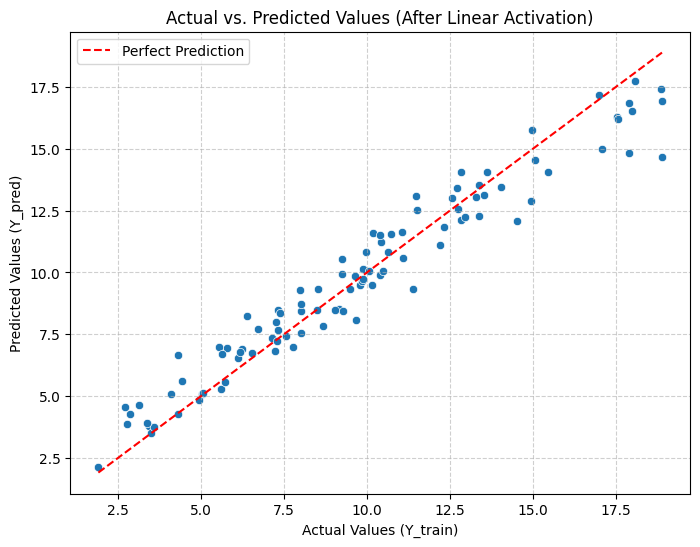

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=Y_train.flatten(), y=Y_pred.flatten())
plt.xlabel('Actual Values (Y_train)')
plt.ylabel('Predicted Values (Y_pred)')
plt.title('Actual vs. Predicted Values (After Linear Activation)')
plt.grid(True, linestyle='--', alpha=0.6)

# Add a diagonal line for perfect prediction
max_val = max(Y_train.max(), Y_pred.max())
min_val = min(Y_train.min(), Y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.legend()
plt.show()

In [40]:
final_activations = model_complex.activations_history['A1'][-1]
zero_activations_count = np.sum(final_activations == 0)
total_activations_count = final_activations.size
percentage_zero_activations = (zero_activations_count / total_activations_count) * 100

print(f"Percentage of zero activations in the final epoch (Hidden Layer A1): {percentage_zero_activations:.2f}%")


Percentage of zero activations in the final epoch (Hidden Layer A1): 60.67%
